In [9]:
import subprocess
subprocess.run(['pip', 'install', 'torch', 'torchvision', '--index-url', 'https://download.pytorch.org/whl/cpu'])

CompletedProcess(args=['pip', 'install', 'torch', 'torchvision', '--index-url', 'https://download.pytorch.org/whl/cpu'], returncode=0)

In [10]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [11]:
IMG_DIR = Path(r'C:\Users\hp\Downloads\archive\For Training\Cropped')

train_df = pd.read_csv(r'C:\Users\hp\Downloads\CoreProject\train_split.csv')
val_df   = pd.read_csv(r'C:\Users\hp\Downloads\CoreProject\val_split.csv')
test_df  = pd.read_csv(r'C:\Users\hp\Downloads\CoreProject\test_split.csv')

CLASS_NAMES = ['spheroidite', 'network', 'spheroidite+widmanstatten']
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(class_to_idx)

Train: 385 | Val: 82 | Test: 83
{'spheroidite': 0, 'network': 1, 'spheroidite+widmanstatten': 2}


In [12]:
train_transforms = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(90),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

val_transforms = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

class MicrostructureDataset(Dataset):
    def __init__(self, df, img_dir, transform, class_to_idx):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.img_dir / row['filename']
        img = Image.open(img_path).convert('L')
        img = self.transform(img)
        label = self.class_to_idx[row['primary_microconstituent']]
        return img, label

train_dataset = MicrostructureDataset(train_df, IMG_DIR, train_transforms, class_to_idx)
val_dataset   = MicrostructureDataset(val_df,   IMG_DIR, val_transforms,   class_to_idx)
test_dataset  = MicrostructureDataset(test_df,  IMG_DIR, val_transforms,   class_to_idx)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')

# Quick sanity check
imgs, labels = next(iter(train_loader))
print(f'Batch shape: {imgs.shape}')
print(f'Labels: {labels}')

Train batches: 25
Val batches:   6
Batch shape: torch.Size([16, 3, 224, 224])
Labels: tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0])


In [5]:
# Class weights to handle imbalance (inverse of class frequency)
class_counts = train_df['primary_microconstituent'].value_counts()
weights = [1.0 / class_counts[cls] for cls in CLASS_NAMES]
weights = torch.tensor(weights, dtype=torch.float)
weights = weights / weights.sum()
print(f'Class weights: {weights}')

# Load pretrained ResNet-50
model = models.resnet50(weights='IMAGENET1K_V1')

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer with 3-class head
model.fc = nn.Linear(model.fc.in_features, 3)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=weights.to(device))
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

print('Model ready.')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')

Class weights: tensor([0.1055, 0.3864, 0.5081])
Model ready.
Trainable params: 6147


In [6]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

# Phase 1 — train only final layer (frozen backbone)
print('Phase 1: Training final layer only (10 epochs)')
print('-' * 50)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(10):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = val_epoch(model, val_loader, criterion)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f'Epoch {epoch+1:2d} | Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.3f} | Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.3f}')

Phase 1: Training final layer only (10 epochs)
--------------------------------------------------
Epoch  1 | Train Loss: 1.0260 | Train Acc: 0.475 | Val Loss: 0.5602 | Val Acc: 0.805
Epoch  2 | Train Loss: 0.7729 | Train Acc: 0.743 | Val Loss: 0.3911 | Val Acc: 0.866
Epoch  3 | Train Loss: 0.5880 | Train Acc: 0.743 | Val Loss: 0.3804 | Val Acc: 0.780
Epoch  4 | Train Loss: 0.5345 | Train Acc: 0.792 | Val Loss: 0.3422 | Val Acc: 0.829
Epoch  5 | Train Loss: 0.5096 | Train Acc: 0.766 | Val Loss: 0.3846 | Val Acc: 0.756
Epoch  6 | Train Loss: 0.5202 | Train Acc: 0.784 | Val Loss: 0.3118 | Val Acc: 0.854
Epoch  7 | Train Loss: 0.4746 | Train Acc: 0.790 | Val Loss: 0.3076 | Val Acc: 0.841
Epoch  8 | Train Loss: 0.3804 | Train Acc: 0.803 | Val Loss: 0.4235 | Val Acc: 0.902
Epoch  9 | Train Loss: 0.4685 | Train Acc: 0.821 | Val Loss: 0.2553 | Val Acc: 0.878
Epoch 10 | Train Loss: 0.3788 | Train Acc: 0.865 | Val Loss: 0.2601 | Val Acc: 0.866


In [7]:
# Phase 2 — unfreeze all layers and fine-tune
print('Phase 2: Fine-tuning all layers (10 epochs)')
print('-' * 50)

# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# Lower learning rate for fine-tuning
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

for epoch in range(10):
    tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
    vl_loss, vl_acc = val_epoch(model, val_loader, criterion)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f'Epoch {epoch+1:2d} | Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.3f} | Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc:.3f}')

Phase 2: Fine-tuning all layers (10 epochs)
--------------------------------------------------
Epoch  1 | Train Loss: 0.3507 | Train Acc: 0.831 | Val Loss: 0.2088 | Val Acc: 0.890
Epoch  2 | Train Loss: 0.2731 | Train Acc: 0.878 | Val Loss: 0.1968 | Val Acc: 0.890
Epoch  3 | Train Loss: 0.3582 | Train Acc: 0.860 | Val Loss: 0.2025 | Val Acc: 0.866
Epoch  4 | Train Loss: 0.2681 | Train Acc: 0.896 | Val Loss: 0.1872 | Val Acc: 0.878
Epoch  5 | Train Loss: 0.3088 | Train Acc: 0.899 | Val Loss: 0.1881 | Val Acc: 0.878
Epoch  6 | Train Loss: 0.2305 | Train Acc: 0.904 | Val Loss: 0.1672 | Val Acc: 0.915
Epoch  7 | Train Loss: 0.1846 | Train Acc: 0.922 | Val Loss: 0.1541 | Val Acc: 0.890
Epoch  8 | Train Loss: 0.1525 | Train Acc: 0.932 | Val Loss: 0.1858 | Val Acc: 0.878
Epoch  9 | Train Loss: 0.1764 | Train Acc: 0.927 | Val Loss: 0.1817 | Val Acc: 0.890
Epoch 10 | Train Loss: 0.1470 | Train Acc: 0.943 | Val Loss: 0.1767 | Val Acc: 0.866


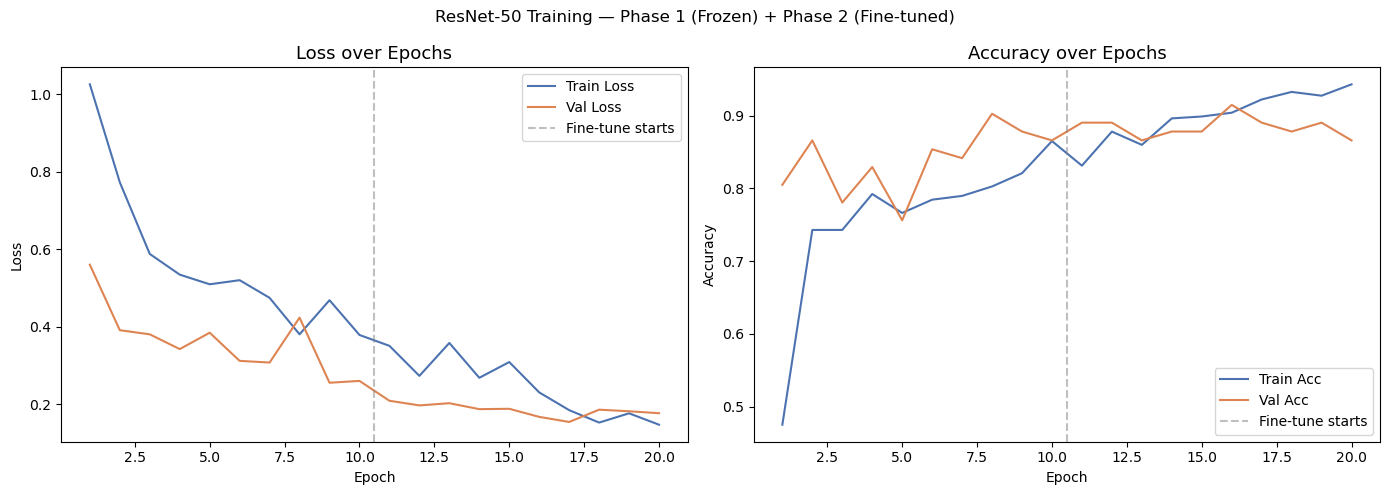

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, 21)
axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='#4C72B0')
axes[0].plot(epochs, history['val_loss'], label='Val Loss', color='#DD8452')
axes[0].axvline(x=10.5, color='gray', linestyle='--', alpha=0.5, label='Fine-tune starts')
axes[0].set_title('Loss over Epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train Acc', color='#4C72B0')
axes[1].plot(epochs, history['val_acc'], label='Val Acc', color='#DD8452')
axes[1].axvline(x=10.5, color='gray', linestyle='--', alpha=0.5, label='Fine-tune starts')
axes[1].set_title('Accuracy over Epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('ResNet-50 Training — Phase 1 (Frozen) + Phase 2 (Fine-tuned)', fontsize=12)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

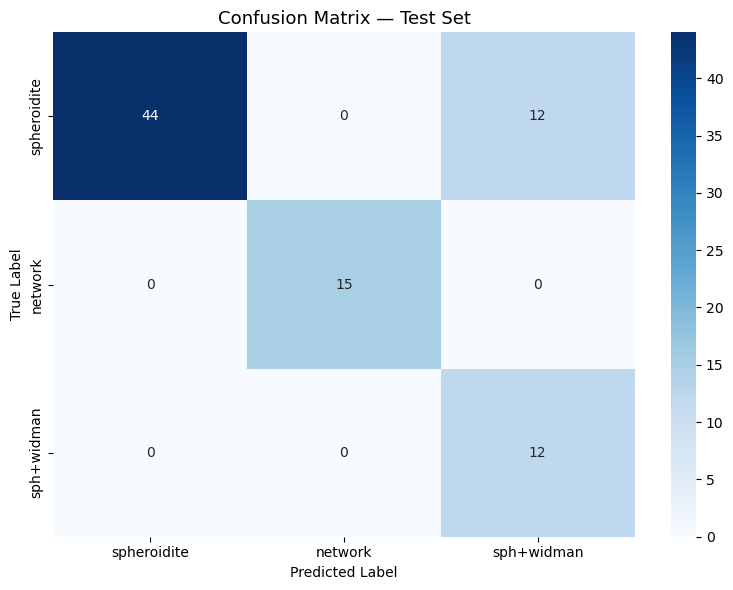

              precision    recall  f1-score   support

 spheroidite       1.00      0.79      0.88        56
     network       1.00      1.00      1.00        15
  sph+widman       0.50      1.00      0.67        12

    accuracy                           0.86        83
   macro avg       0.83      0.93      0.85        83
weighted avg       0.93      0.86      0.87        83



In [9]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
short_names = ['spheroidite', 'network', 'sph+widman']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names)
plt.title('Confusion Matrix — Test Set', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(all_labels, all_preds, target_names=short_names))

In [10]:
torch.save(model.state_dict(), 'resnet50_microstructure.pth')
print('Model saved.')

Model saved.


In [11]:
import subprocess
subprocess.run(['pip', 'install', 'grad-cam'])

CompletedProcess(args=['pip', 'install', 'grad-cam'], returncode=0)

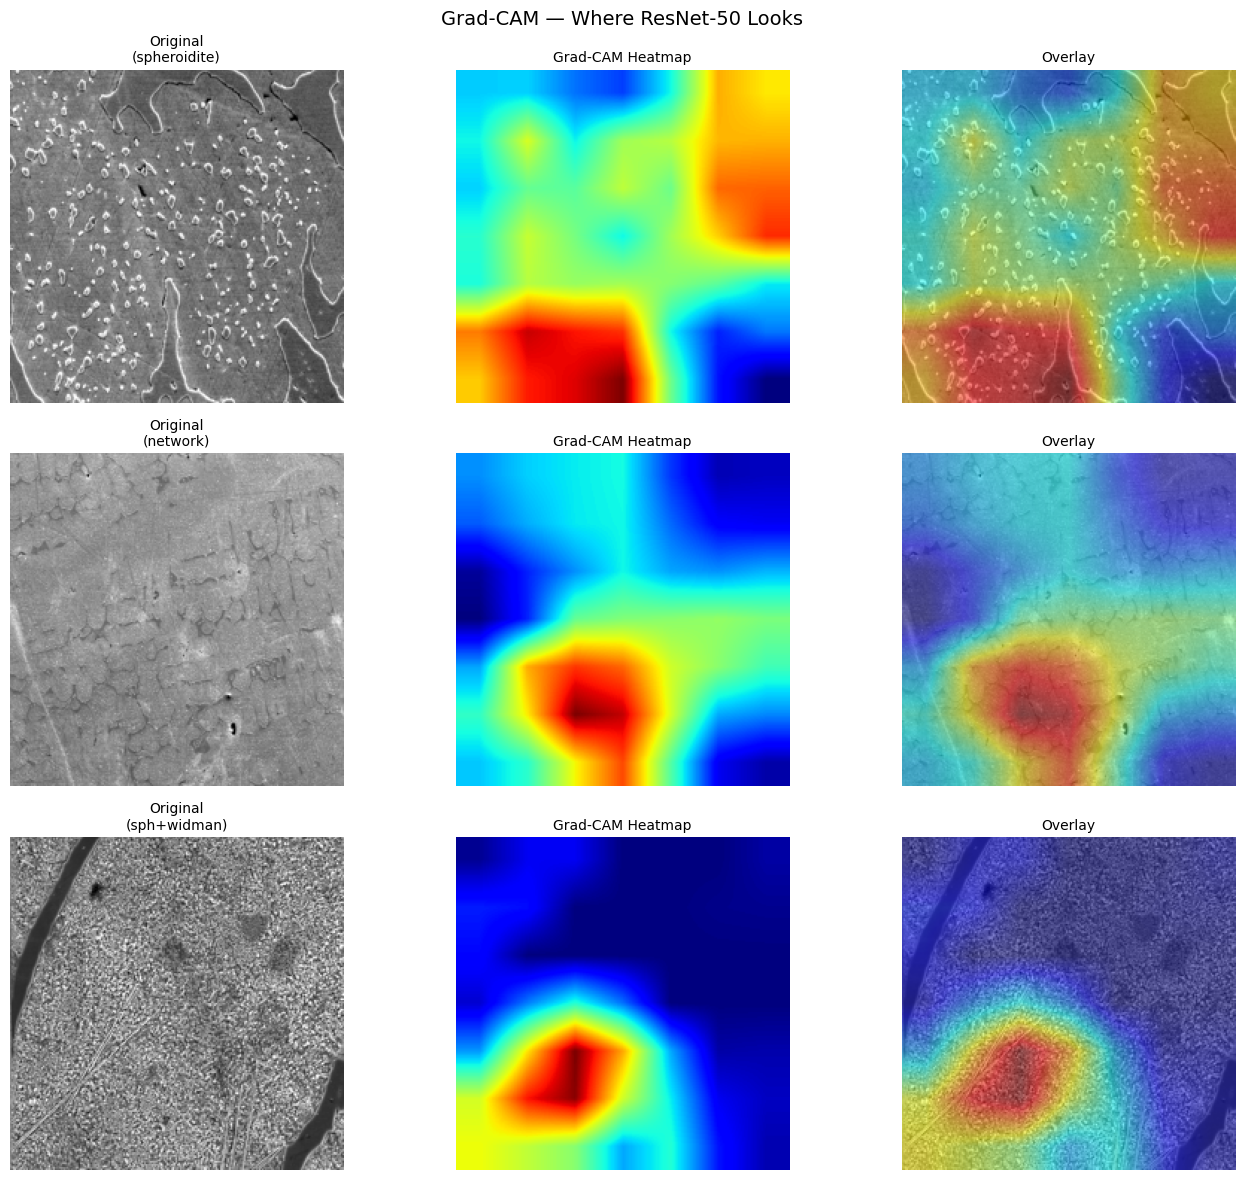

In [12]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np
import cv2

# Target the last conv layer of ResNet-50
target_layers = [model.layer4[-1]]

# Pick one sample per class from test set
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
fig.suptitle('Grad-CAM — Where ResNet-50 Looks', fontsize=14)

short_names = ['spheroidite', 'network', 'sph+widman']

with GradCAM(model=model, target_layers=target_layers) as cam:
    for row, cls_idx in enumerate(range(3)):
        # Get a correctly predicted sample for this class
        cls_name = CLASS_NAMES[cls_idx]
        cls_df = test_df[test_df['primary_microconstituent'] == cls_name]
        
        for _, row_data in cls_df.iterrows():
            img_path = IMG_DIR / row_data['filename']
            img_pil = Image.open(img_path).convert('L')
            img_tensor = val_transforms(img_pil).unsqueeze(0).to(device)
            
            pred = model(img_tensor).argmax(1).item()
            if pred == cls_idx:  # only show correct predictions
                break
        
        # Original image
        img_np = np.array(img_pil.resize((224, 224)), dtype=np.float32) / 255.0
        img_rgb = np.stack([img_np] * 3, axis=-1)
        
        # Grad-CAM
        targets = [ClassifierOutputTarget(cls_idx)]
        grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0]
        cam_image = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)
        
        # Plot
        axes[row][0].imshow(img_np, cmap='gray')
        axes[row][0].set_title(f'Original\n({short_names[cls_idx]})', fontsize=10)
        axes[row][0].axis('off')
        
        axes[row][1].imshow(grayscale_cam, cmap='jet')
        axes[row][1].set_title('Grad-CAM Heatmap', fontsize=10)
        axes[row][1].axis('off')
        
        axes[row][2].imshow(cam_image)
        axes[row][2].set_title('Overlay', fontsize=10)
        axes[row][2].axis('off')

plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 3)
model.load_state_dict(torch.load('resnet50_microstructure.pth', map_location=device))
model = model.to(device)
model.eval()
print('Model loaded from disk.')

Model loaded from disk.


Feature matrix shape: (83, 2048)


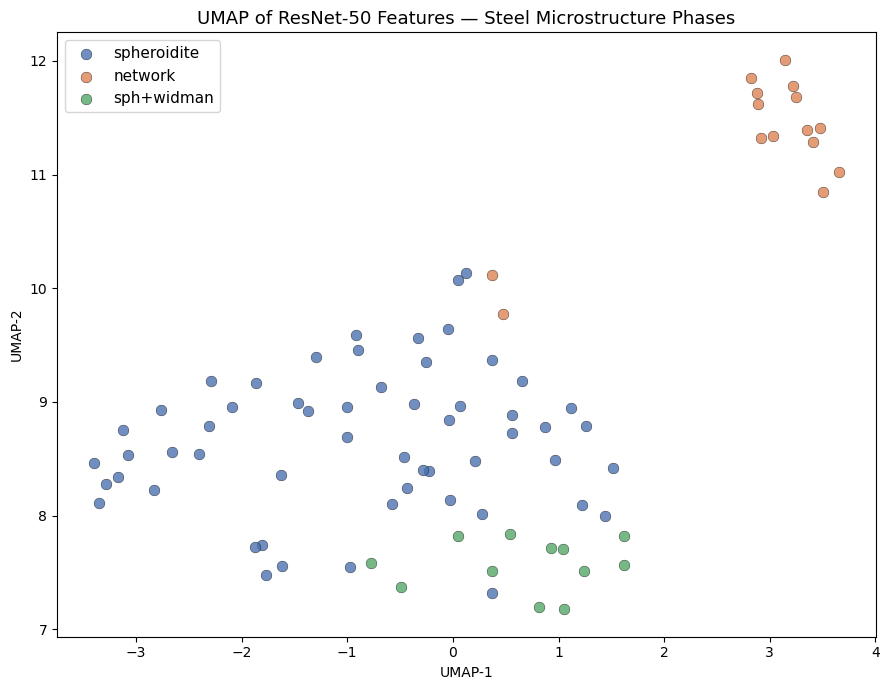

In [15]:
import umap.umap_ as umap
import subprocess
subprocess.run(['pip', 'install', 'umap-learn'])

# Extract features from second-to-last layer (before final FC)
feature_extractor = nn.Sequential(*list(model.children())[:-1])
feature_extractor.eval()

features, true_labels = [], []

with torch.no_grad():
    for imgs, labels in DataLoader(test_dataset, batch_size=16, shuffle=False):
        imgs = imgs.to(device)
        feats = feature_extractor(imgs)
        feats = feats.squeeze(-1).squeeze(-1).cpu().numpy()
        features.append(feats)
        true_labels.extend(labels.numpy())

features = np.concatenate(features, axis=0)
print(f'Feature matrix shape: {features.shape}')

# UMAP
reducer = umap.UMAP(n_components=2, random_state=SEED)
embedding = reducer.fit_transform(features)

# Plot
colors = ['#4C72B0', '#DD8452', '#55A868']
short_names = ['spheroidite', 'network', 'sph+widman']

plt.figure(figsize=(9, 7))
for i, cls in enumerate(short_names):
    mask = np.array(true_labels) == i
    plt.scatter(embedding[mask, 0], embedding[mask, 1],
                c=colors[i], label=cls, alpha=0.8, s=60, edgecolors='k', linewidths=0.3)

plt.title('UMAP of ResNet-50 Features — Steel Microstructure Phases', fontsize=13)
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('umap_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
print('=' * 55)
print('   PROJECT SUMMARY — Steel Microstructure Classifier')
print('=' * 55)
print(f'Dataset       : UHCS (Kaggle) — 550 images, 3 classes')
print(f'Model         : ResNet-50 (ImageNet pretrained)')
print(f'Training      : Phase 1 (frozen, 10 epochs) + Phase 2 (fine-tune, 10 epochs)')
print(f'Test Accuracy : 86%')
print(f'Best Val Acc  : 91.5% (epoch 16)')
print()
print('Per-class F1:')
print(f'  spheroidite        : 0.88')
print(f'  network            : 1.00')
print(f'  sph+widmanstatten  : 0.67')
print()
print('Key findings:')
print('  - Network cementite perfectly classified (F1=1.00)')
print('  - UMAP shows clear phase separation in feature space')
print('  - Main confusion: spheroidite vs sph+widmanstatten')
print('    (expected — shared microstructural features)')
print('  - Grad-CAM physically meaningful for network cementite')
print()
print('Saved files:')
print('  resnet50_microstructure.pth')
print('  training_curves.png')
print('  confusion_matrix.png')
print('  gradcam_results.png')
print('  umap_features.png')
print('=' * 55)

   PROJECT SUMMARY — Steel Microstructure Classifier
Dataset       : UHCS (Kaggle) — 550 images, 3 classes
Model         : ResNet-50 (ImageNet pretrained)
Training      : Phase 1 (frozen, 10 epochs) + Phase 2 (fine-tune, 10 epochs)
Test Accuracy : 86%
Best Val Acc  : 91.5% (epoch 16)

Per-class F1:
  spheroidite        : 0.88
  network            : 1.00
  sph+widmanstatten  : 0.67

Key findings:
  - Network cementite perfectly classified (F1=1.00)
  - UMAP shows clear phase separation in feature space
  - Main confusion: spheroidite vs sph+widmanstatten
    (expected — shared microstructural features)
  - Grad-CAM physically meaningful for network cementite

Saved files:
  resnet50_microstructure.pth
  training_curves.png
  confusion_matrix.png
  gradcam_results.png
  umap_features.png
